## Train a simple convnet on the Fashion MNIST dataset

In this, we will see how to deal with image data and train a convnet for image classification task.

### Load the  `fashion_mnist`  dataset

** Use keras.datasets to load the dataset **

In [0]:
from keras.datasets import fashion_mnist
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

In [0]:
import tensorflow as tf


### Find no.of samples are there in training and test datasets

In [6]:
x_train.shape

(60000, 28, 28)

In [0]:
# Training Data set is 60000 

In [8]:
y_train.shape

(60000,)

In [0]:
# Test Data set is 60000 

In [10]:
x_test.shape

(10000, 28, 28)

In [11]:
y_test.shape

(10000,)

### Find dimensions of an image in the dataset

In [0]:
# Dimension is 28 x 28

### Convert train and test labels to one hot vectors

** check `keras.utils.to_categorical()` **

In [0]:
y_test = tf.keras.utils.to_categorical(y_test, num_classes=10)

In [0]:
y_train = tf.keras.utils.to_categorical(y_train, num_classes=10)

### Normalize both the train and test image data from 0-255 to 0-1

In [0]:
x_trainN = x_train.astype('float32')
x_testN = x_test.astype('float32')

In [0]:
x_trainN /= 255
x_testN /= 255

### Reshape the data from 28x28 to 28x28x1 to match input dimensions in Conv2D layer in keras

In [0]:
x_trainR = x_trainN.reshape(x_trainN.shape[0], 28, 28, 1)
x_testR = x_testN.reshape(x_testN.shape[0], 28, 28, 1)
input_shape = (28, 28, 1)

### Import the necessary layers from keras to build the model

In [0]:
from keras.models import Sequential
from keras.layers import Dense
from keras import regularizers
from keras import optimizers
from keras.models import Sequential
from keras.layers import Dense, Conv2D, Dropout, Flatten, MaxPooling2D

import keras
import keras.utils
from keras import utils as np_utils

### Build a model 

** with 2 Conv layers having `32 3x3 filters` in both convolutions with `relu activations` and `flatten` before passing the feature map into 2 fully connected layers (or Dense Layers) having 128 and 10 neurons with `relu` and `softmax` activations respectively. Now, using `categorical_crossentropy` loss with `adam` optimizer train the model with early stopping `patience=5` and no.of `epochs=10`. **

In [19]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3), activation='relu'))
model.add(tf.keras.layers.Flatten())
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='softmax'))
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])


#Output layer
#model.add(tf.keras.layers.Dense(len(class_names), activation='softmax'))

W0818 10:50:16.472705 140664375805824 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/tensorflow/python/ops/init_ops.py:1251: calling VarianceScaling.__init__ (from tensorflow.python.ops.init_ops) with dtype is deprecated and will be removed in a future version.
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


In [20]:
# Creating a Sequential Model and adding the layers
model = Sequential()
model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model.add(Dense(128, activation="relu"))
model.add(Dense(10, activation="softmax"))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        verbose=1)
]

model.fit(x_trainR, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks
          )

W0818 10:50:16.490870 140664375805824 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:74: The name tf.get_default_graph is deprecated. Please use tf.compat.v1.get_default_graph instead.

W0818 10:50:16.492868 140664375805824 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:517: The name tf.placeholder is deprecated. Please use tf.compat.v1.placeholder instead.

W0818 10:50:16.495839 140664375805824 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:4138: The name tf.random_uniform is deprecated. Please use tf.random.uniform instead.

W0818 10:50:16.551174 140664375805824 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/optimizers.py:790: The name tf.train.Optimizer is deprecated. Please use tf.compat.v1.train.Optimizer instead.

W0818 10:50:16.571707 140664375805824 deprecation_wrappe

Epoch 1/10
60000/60000 [==============================] - 9s 150us/step - loss: 0.3940 - acc: 0.8584
Epoch 2/10
 1664/60000 [..............................] - ETA: 5s - loss: 0.2365 - acc: 0.9075

/usr/local/lib/python3.6/dist-packages/keras/callbacks.py:569: RuntimeWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


60000/60000 [==============================] - 6s 99us/step - loss: 0.2447 - acc: 0.9106
Epoch 3/10
60000/60000 [==============================] - 6s 100us/step - loss: 0.1841 - acc: 0.9321
Epoch 4/10
60000/60000 [==============================] - 6s 99us/step - loss: 0.1381 - acc: 0.9499
Epoch 5/10
60000/60000 [==============================] - 6s 99us/step - loss: 0.1015 - acc: 0.9626
Epoch 6/10
60000/60000 [==============================] - 6s 99us/step - loss: 0.0716 - acc: 0.9728
Epoch 7/10
60000/60000 [==============================] - 6s 99us/step - loss: 0.0500 - acc: 0.9817
Epoch 8/10
60000/60000 [==============================] - 6s 98us/step - loss: 0.0378 - acc: 0.9869
Epoch 9/10
60000/60000 [==============================] - 6s 100us/step - loss: 0.0269 - acc: 0.9903
Epoch 10/10
60000/60000 [==============================] - 6s 100us/step - loss: 0.0221 - acc: 0.9923


### Now, to the above model add `max` pooling layer of `filter size 2x2` and `dropout` layer with `p=0.25` after the 2 conv layers and run the model

In [21]:
# Creating a Sequential Model and adding the layers
model1 = Sequential()
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model1.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(Dropout(0.25))
model1.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model1.add(Dense(128, activation="relu"))
model1.add(Dense(10, activation="softmax"))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks1 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        verbose=1)
]

model1.fit(x_trainR, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks1
          )

W0818 10:51:19.730522 140664375805824 deprecation_wrapper.py:119] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3976: The name tf.nn.max_pool is deprecated. Please use tf.nn.max_pool2d instead.

W0818 10:51:19.741086 140664375805824 deprecation.py:506] From /usr/local/lib/python3.6/dist-packages/keras/backend/tensorflow_backend.py:3445: calling dropout (from tensorflow.python.ops.nn_ops) with keep_prob is deprecated and will be removed in a future version.
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


Epoch 1/10
60000/60000 [==============================] - 5s 86us/step - loss: 0.4322 - acc: 0.8450
Epoch 2/10
 2048/60000 [>.............................] - ETA: 4s - loss: 0.2861 - acc: 0.8901

/usr/local/lib/python3.6/dist-packages/keras/callbacks.py:569: RuntimeWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


60000/60000 [==============================] - 5s 80us/step - loss: 0.2822 - acc: 0.8969
Epoch 3/10
60000/60000 [==============================] - 5s 80us/step - loss: 0.2327 - acc: 0.9146
Epoch 4/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.2003 - acc: 0.9261
Epoch 5/10
60000/60000 [==============================] - 5s 80us/step - loss: 0.1721 - acc: 0.9356
Epoch 6/10
60000/60000 [==============================] - 5s 80us/step - loss: 0.1483 - acc: 0.9451
Epoch 7/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1273 - acc: 0.9529
Epoch 8/10
60000/60000 [==============================] - 5s 80us/step - loss: 0.1143 - acc: 0.9570
Epoch 9/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.0994 - acc: 0.9636
Epoch 10/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.0848 - acc: 0.9684


### Now, to the above model, lets add Data Augmentation 

### Import the ImageDataGenrator from keras and fit the training images

In [0]:
transform_fn = tf.keras.preprocessing.image.ImageDataGenerator(horizontal_flip=True)

In [0]:
transformed_array = transform_fn.random_transform(x_trainR)

In [0]:
# Creating a Sequential Model and adding the layers
model1 = Sequential()
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model1.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model1.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model1.add(Dropout(0.25))
model1.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model1.add(Dense(128, activation="relu"))
model1.add(Dense(10, activation="softmax"))

model1.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks1 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        verbose=1)
]

#### Showing 5 versions of the first image in training dataset using image datagenerator.flow()

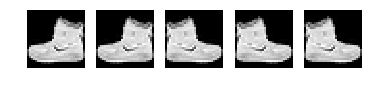

In [25]:
from matplotlib import pyplot as plt
gen = transform_fn.flow(transformed_array[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze(), cmap='gray')
    plt.plot()
plt.show()

### Run the above model using fit_generator()

In [26]:
model1.fit(transformed_array, y_train,
          epochs=10,
          batch_size=64,
          callbacks=callbacks1
          )


Epoch 1/10
60000/60000 [==============================] - 5s 85us/step - loss: 0.4218 - acc: 0.8504
Epoch 2/10
 2112/60000 [>.............................] - ETA: 4s - loss: 0.2927 - acc: 0.8892

/usr/local/lib/python3.6/dist-packages/keras/callbacks.py:569: RuntimeWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: loss,acc
  (self.monitor, ','.join(list(logs.keys()))), RuntimeWarning


60000/60000 [==============================] - 5s 79us/step - loss: 0.2758 - acc: 0.8984
Epoch 3/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.2251 - acc: 0.9178
Epoch 4/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1931 - acc: 0.9295
Epoch 5/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1670 - acc: 0.9378
Epoch 6/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1459 - acc: 0.9454
Epoch 7/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1245 - acc: 0.9530
Epoch 8/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.1070 - acc: 0.9600
Epoch 9/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.0937 - acc: 0.9648
Epoch 10/10
60000/60000 [==============================] - 5s 79us/step - loss: 0.0792 - acc: 0.9697


###  Report the final train and validation accuracy

In [27]:
model.evaluate(x_testR,y_test)

10000/10000 [==============================] - 1s 59us/step


[0.44589818478608506, 0.9063]

In [28]:
model.evaluate(x_trainR, y_train)

60000/60000 [==============================] - 3s 50us/step


[0.02371889320870202, 0.9916833333333334]

## **DATA AUGMENTATION ON CIFAR10 DATASET**

One of the best ways to improve the performance of a Deep Learning model is to add more data to the training set. Aside from gathering more instances from the wild that are representative of the distinction task, we want to develop a set of methods that enhance the data we already have. There are many ways to augment existing datasets and produce more robust models. In the image domain, these are done to utilize the full power of the convolutional neural network, which is able to capture translational invariance. This translational invariance is what makes image recognition such a difficult task in the first place. You want the dataset to be representative of the many different positions, angles, lightings, and miscellaneous distortions that are of interest to the vision task.

### **Import neessary libraries for data augmentation**

In [0]:
from keras.datasets import cifar10


### **Load CIFAR10 dataset**

In [0]:
(x_trainC, y_trainC), (x_testC, y_testC) = cifar10.load_data()

In [31]:
x_trainC.shape

(50000, 32, 32, 3)

### **Create a data_gen funtion to genererator with image rotation,shifting image horizontally and vertically with random flip horizontally.**

1.   List item
2.   List item



In [0]:
data_gen1= tf.keras.preprocessing.image.ImageDataGenerator(
    featurewise_center=True,
    featurewise_std_normalization=True,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True)

### **Prepare/fit the generator.**

In [0]:
data_gen1.fit(x_trainC)

In [0]:
# Creating a Sequential Model and adding the layers
model2 = Sequential()
model2.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model2.add(Conv2D(32, kernel_size=(3,3), input_shape=input_shape, activation = 'relu'))
model2.add(keras.layers.MaxPool2D(pool_size=(2,2)))
model2.add(Dropout(0.25))
model2.add(Flatten()) # Flattening the 2D arrays for fully connected layers
model2.add(Dense(128, activation="relu"))
model2.add(Dense(10, activation="softmax"))

model2.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

callbacks1 = [
    keras.callbacks.EarlyStopping(
        # Stop training when `val_loss` is no longer improving
        monitor='val_loss',
        # "no longer improving" being defined as "no better than 1e-2 less"
        min_delta=1e-2,
        # "no longer improving" being further defined as "for at least 2 epochs"
        patience=5,
        verbose=1)
]

### **Generate 5 images for 1 of the image of CIFAR10 train dataset.**

W0818 10:53:19.382650 140664375805824 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:53:19.398231 140664375805824 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:53:19.411444 140664375805824 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:53:19.427176 140664375805824 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
W0818 10:53:19.440473 140664375805824 image.py:648] Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


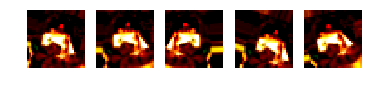

In [37]:
from matplotlib import pyplot as plt
gen = data_gen1.flow(x_trainC[0:1], batch_size=1)
for i in range(1, 6):
    plt.subplot(1,5,i)
    plt.axis("off")
    plt.imshow(gen.next().squeeze())
    plt.plot()
plt.show()